# Гауссовский байесовский классификатор

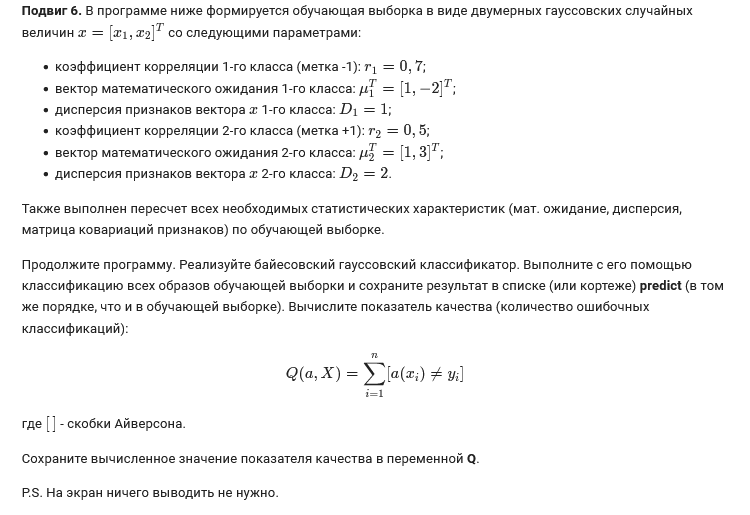

In [27]:
import numpy as np

np.random.seed(0)

# исходные параметры распределений двух классов
r1 = 0.7
D1 = 1.0
mean1 = [1, -2]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

r2 = 0.5
D2 = 2.0
mean2 = [1, 3]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

# моделирование обучающей выборки
N = 1000
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T

# обучающая выборка для байесовского классификатора (стандартный формат)
x_train = np.hstack([x1, x2]).T
y_train = np.hstack([np.ones(N) * -1, np.ones(N)])

# вычисление оценок математических ожиданий
mm1 = np.mean(x1.T, axis=0)
mm2 = np.mean(x2.T, axis=0)

# вычисление ковариационных матриц
a = (x1.T - mm1).T
VV1 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

a = (x2.T - mm2).T
VV2 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

# параметры для гауссовского байесовского классификатора
Py1, L1 = 0.5, 1  # вероятности появления классов
Py2, L2 = 1 - Py1, 1  # и величины штрафов неверной классификации

# здесь продолжайте программу
b = lambda x, v, m, l, py: np.log(l * py) - 0.5 * (x - m) @ np.linalg.inv(v) @ (x - m).T - 0.5 * np.log(np.linalg.det(v))

br1 = np.array([b(x, VV1, mm1, L1, Py1) for x in x_train])
br2 = np.array([b(x, VV2, mm2, L2, Py2) for x in x_train])

predict = np.where(br1 > br2, -1, 1)

Q = np.sum(predict != y_train)

print(predict)
print(Q)

[-1 -1 -1 ...  1  1  1]
4


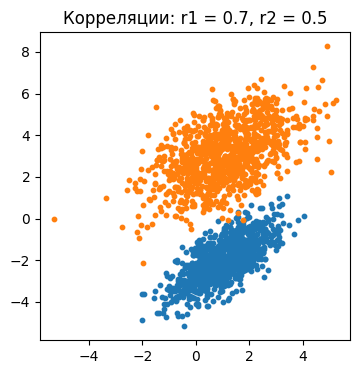

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.title(f"Корреляции: r1 = {r1}, r2 = {r2}")
plt.scatter(x1[0], x1[1], s=10)
plt.scatter(x2[0], x2[1], s=10)
plt.show()

In [ ]:
import numpy as np

np.random.seed(0)

# исходные параметры распределений двух классов
r1 = 0.7
D1 = 1.0
mean1 = [-1, -2, -1]
V1 = [[D1, D1 * r1, D1*r1*r1], [D1 * r1, D1, D1*r1], [D1*r1*r1, D1*r1, D1]]

r2 = 0.5
D2 = 2.0
mean2 = [1, 2, 1]
V2 = [[D2, D2 * r2, D2*r2*r2], [D2 * r2, D2, D2*r2], [D2*r2*r2, D2*r2, D2]]

# моделирование обучающей выборки
N = 1000
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T

x_train = np.hstack([x1, x2]).T
y_train = np.hstack([np.ones(N) * -1, np.ones(N)])

# здесь продолжайте программу

# вычисление оценок математических ожиданий
mm1 = np.mean(x1.T, axis=0)
mm2 = np.mean(x2.T, axis=0)

# вычисление ковариационных матриц
a = (x1.T - mm1).T
# VV1 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N, np.dot(a[0], a[2]) / N],
                # [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N, np.dot(a[1], a[2]) / N],
                # [np.dot(a[2], a[0]) / N, np.dot(a[2], a[1]) / N, np.dot(a[2], a[2]) / N]])
VV1 = np.cov(a)

a = (x2.T - mm2).T
VV2 = np.cov(a)

# параметры для гауссовского байесовского классификатора
Py1, L1 = 0.5, 1  # вероятности появления классов
Py2, L2 = 1 - Py1, 1  # и величины штрафов неверной классификации

b = lambda x, v, m, l, py: np.log(l * py) - 0.5 * (x - m) @ np.linalg.inv(v) @ (x - m).T - 0.5 * np.log(np.linalg.det(v))

br1 = np.array([b(x, VV1, mm1, L1, Py1) for x in x_train])
br2 = np.array([b(x, VV2, mm2, L2, Py2) for x in x_train])

predict = np.where(br1 > br2, -1, 1)

Q = np.sum(predict != y_train)

print(predict)
print(Q)

[-1 -1 -1 ...  1  1  1]
78


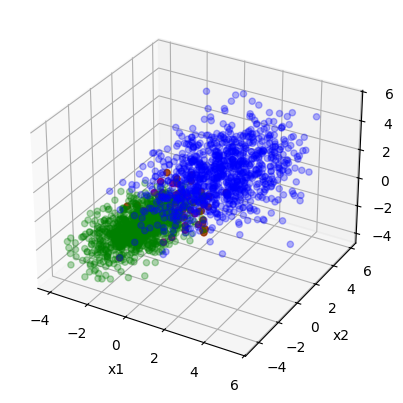

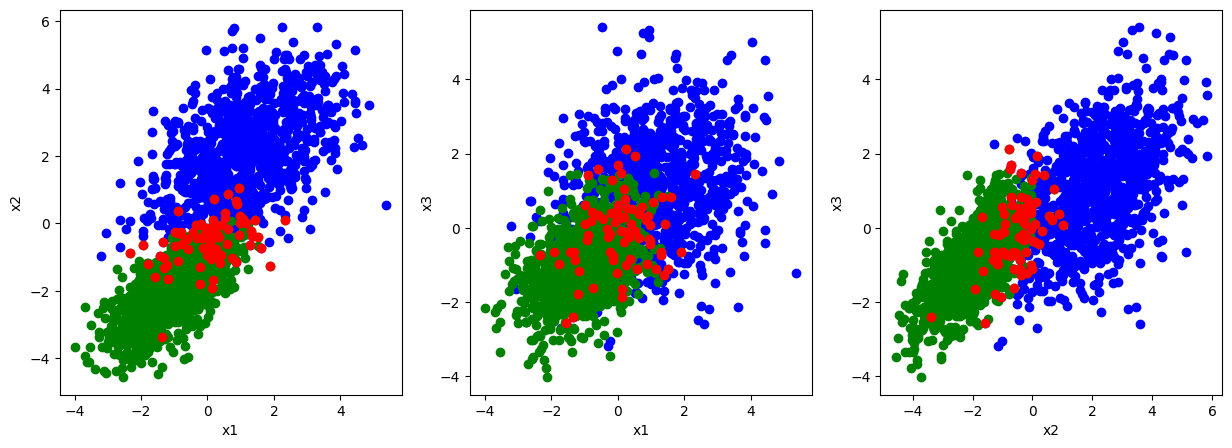

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

fig = plt.figure()
ax = plt.axes(projection ='3d')
ax.scatter3D(x_train[y_train==1][:,0], x_train[y_train==1][:,1], x_train[y_train==1][:,2], color='blue', alpha=0.3)
ax.scatter3D(x_train[y_train==-1][:,0], x_train[y_train==-1][:,1], x_train[y_train==-1][:,2], color='green', alpha=0.3)
ax.scatter3D(x_train[y_train!=predict][:,0], x_train[y_train!=predict][:,1], x_train[y_train!=predict][:,2], color='red', alpha=0.8)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')

fig, axs = plt.subplots(figsize=(15, 5), ncols=3)
axs[0].scatter(x_train[y_train==1][:,0], x_train[y_train==1][:,1], color='blue')
axs[0].scatter(x_train[y_train==-1][:,0], x_train[y_train==-1][:,1], color='green')
axs[0].scatter(x_train[y_train!=predict][:,0], x_train[y_train!=predict][:,1], color='red')
axs[0].set_xlabel('x1')
axs[0].set_ylabel('x2')

axs[1].scatter(x_train[y_train==1][:,0], x_train[y_train==1][:,2], color='blue')
axs[1].scatter(x_train[y_train==-1][:,0], x_train[y_train==-1][:,2], color='green')
axs[1].scatter(x_train[y_train!=predict][:,0], x_train[y_train!=predict][:,2], color='red')
axs[1].set_xlabel('x1')
axs[1].set_ylabel('x3')

axs[2].scatter(x_train[y_train==1][:,1], x_train[y_train==1][:,2], color='blue')
axs[2].scatter(x_train[y_train==-1][:,1], x_train[y_train==-1][:,2], color='green')
axs[2].scatter(x_train[y_train!=predict][:,1], x_train[y_train!=predict][:,2], color='red')
axs[2].set_xlabel('x2')
axs[2].set_ylabel('x3')

plt.show()